<a href="https://colab.research.google.com/github/orca3/llm-model-serving/blob/main/ch07/LMCache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sat Oct 11 02:01:19 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!uv pip install lmcache==0.3.5 vllm==0.10.1 torch

Using Python 3.12.11 environment at: /usr
Resolved 152 packages in 1.14s
Prepared 55 packages in 24.87s
Uninstalled 12 packages in 909ms
Installed 55 packages in 235ms
 + aiofile==3.9.0
 + astor==0.8.1
 + awscrt==0.28.1
 + blake3==1.0.7
 + caio==0.9.24
 + cbor2==5.7.0
 - click==8.3.0
 + click==8.2.1
 + compressed-tensors==0.10.2
 + cufile-python==0.1.1
 + depyf==0.19.0
 + diskcache==5.6.3
 + dnspython==2.8.0
 + email-validator==2.3.0
 + fastapi-cli==0.0.13
 + fastapi-cloud-cli==0.3.1
 + gguf==0.17.1
 + httptools==0.7.1
 + infinistore==0.2.35
 + interegular==0.3.3
 - lark==1.3.0
 + lark==1.2.2
 + llguidance==0.7.30
 - llvmlite==0.43.0
 + llvmlite==0.44.0
 + lm-format-enforcer==0.10.12
 + lmcache==0.3.5
 + mistral-common==1.8.5
 + msgspec==0.19.0
 + ninja==1.13.0
 - numba==0.60.0
 + numba==0.61.2
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.5.1.17
 - nvidia-cusparselt-cu12==0.7.1
 + nvidia-cusparselt-cu12==0.6.3
 - nvidia-nccl-cu12==2.27.3
 + nvidia-nccl-cu12==2.26.2
 + openai

In [ ]:
#!pip install lmcache==0.2.1

In [ ]:
#!pip install vllm==0.8.5

In [ ]:
#!pip install torch==2.6.0

In [ ]:
import torch
#import vllm.distributed.kv_transfer.kv_connector.v1.lmcache_connector

In [ ]:
import lmcache
import vllm
from importlib.metadata import version
print(version("lmcache"))
print(version("vllm"))
print(version("torch"))
print(version("numpy"))

0.3.5
0.10.1
2.7.1
2.0.2


In [ ]:
!nvidia-smi

Sat Oct 11 02:01:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pkill -f "vllm serve"

In [ ]:
%%bash

export LMCACHE_USE_EXPERIMENTAL=True

export LMCACHE_CHUNK_SIZE=256
# Enable CPU memory backend
export LMCACHE_LOCAL_CPU=True # default
# 5GB of Pinned CPU memory
export LMCACHE_MAX_LOCAL_CPU_SIZE=150.0 # default
#export LMCACHE_REMOTE_SERDE=cachegen
export LMCACHE_USE_LAYERWISE=False

# export LMCACHE_CHUNK_SIZE=2048
# export LMCACHE_LOCAL_DISK="local_kv_cache/"
# export LMCACHE_MAX_LOCAL_DISK_SIZE=120.0

# Start the vllm server
nohup vllm serve \
  Qwen/Qwen3-14B \
  --disable-log-requests \
  --kv-transfer-config '{"kv_connector":"LMCacheConnectorV1","kv_role":"kv_both"}' \
  --max-model-len 40960 \
  --gpu-memory-utilization 0.9 \
  > vllm.log 2>&1 &

In [ ]:
import time
import requests
from collections import deque

def tail_log(filename, n=2):
    """Read and print the last n lines of a log file."""
    try:
        with open(filename, 'r') as f:
            last_lines = deque(f, maxlen=n)
        print(f"\n📜 Last {n} lines from {filename}:")
        for line in last_lines:
            print(line.rstrip())
    except FileNotFoundError:
        print(f"⚠️ Log file {filename} not found.")
    except Exception as e:
        print(f"⚠️ Error reading log file: {e}")

def check_vllm_status():
    max_retries = 100
    wait_time = 10  # seconds

    print("⏳ Waiting for vLLM server to become healthy...")

    for i in range(max_retries):
        try:
            r = requests.get("http://127.0.0.1:8000/health")
            if r.ok:
                print("✅ vLLM server is healthy and ready!")
                tail_log("vllm.log", n=2)
                break
        except Exception:
            print(f"Attempt {i+1}: Not ready yet...")

        # Always print the last two lines of the log each iteration
        tail_log("vllm.log", n=2)

        time.sleep(wait_time)
    else:
        print("❌ Timed out waiting for vLLM server to start.")
        tail_log("vllm.log", n=2)

check_vllm_status()

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm.log:
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm.log:
W0000 00:00:1760151083.417728   16768 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
INFO 10-11 02:51:29 [__init__.py:241] Automatically detected platform cuda.
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=16768) INFO 10-11 02:51:31 [api_server.py:1805] vLLM API server version 0.10.1
(APIServer pid=16768) INFO 10-11 02:51:31 [utils.py:326] non-default args: {'model_tag': 'Qwen/Qwen3-14B', 'model': 'Qwen/Qwen3-14B', 'max_model_len': 40960, 'kv_transfer_config': KVTransferConfig(kv_connector='LMCacheConnectorV1', engine_id='6520002a-0e84-463d-b037-66f85f462fd9', kv_buffer_device='cuda', kv_buffer_size=1000000000.0, kv_role='kv_both', kv_rank=None, kv_parallel_size=1, kv_ip='127.0.0.1', kv_port=14579, kv_conne

In [ ]:
from openai import OpenAI


# Modify OpenAI's API key and API base to use vLLM's API server.
openai_api_key = "EMPTY"
openai_api_base = "http://localhost:8000/v1"
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)
model_id="Qwen/Qwen3-14B"

In [ ]:
from openai import OpenAI

import argparse
import contextlib
import os
import time
from dataclasses import asdict

#from lmcache.experimental.cache_engine import LMCacheEngineBuilder
#from lmcache.integration.vllm.utils import ENGINE_NAME

from vllm import LLM, SamplingParams
from vllm.config import KVTransferConfig
from vllm.engine.arg_utils import EngineArgs

# Modify OpenAI's API key and API base to use vLLM's API server.
openai_api_key = "EMPTY"
openai_api_base = "http://localhost:8000/v1"
client = OpenAI(
    api_key=openai_api_key,
    base_url=openai_api_base,
)

sampling_params = SamplingParams(temperature=0,
                                 top_p=0.95,
                                 max_tokens=10)

def print_output_online(
    client,
    prompt: list[str],
    sampling_params: SamplingParams,
    req_str: str,
):
    # Should be able to see logs like the following:
    # `LMCache INFO: Storing KV cache for 6006 out of 6006 tokens for request 0`
    # This indicates that the KV cache has been stored in LMCache.
    start = time.time()
    completion = client.completions.create(model=model_id,
                                              prompt=prompt)
    print("Completion result:", completion)
    print("-" * 50)
    # for output in outputs:
    #     generated_text = output.outputs[0].text
    #     print(f"Generated text: {generated_text!r}")
    time_elapsed = time.time() - start
    print(f"Generation took {time_elapsed:.2f} seconds, "
          f"{req_str} request done.")
    print("-" * 50)
    return time_elapsed

In [ ]:
time_cold_lmcache = []
for i in range(30)[::-1]:
    print('First time', i)
    shared_prompt = f"Hello this is now a brand new prompt, how are you? {i}"
    auto_prompt = shared_prompt*2000 + "Hello, my name is"

    time_cold_lmcache.append(print_output_online(client, auto_prompt, sampling_params, "auto"))

time_warm_lmcache = []
for i in range(30):
    print('Second time', i)
    shared_prompt = f"Hello this is now a brand new prompt, how are you? {i}"
    auto_prompt = shared_prompt*2000 + "Hello, my name is"

    time_warm_lmcache.append(print_output_online(client, auto_prompt, sampling_params, "auto"))

First time 29
Completion result: Completion(id='cmpl-b30b4661847a475b9b64e21062b640b1', choices=[CompletionChoice(finish_reason='length', index=0, logprobs=None, text=" Qwen, and I'm a large language model developed by Alibaba Cloud. I", stop_reason=None, prompt_logprobs=None)], created=1760151349, model='Qwen/Qwen3-14B', object='text_completion', system_fingerprint=None, usage=CompletionUsage(completion_tokens=16, prompt_tokens=32005, total_tokens=32021, completion_tokens_details=None, prompt_tokens_details=None), service_tier=None, kv_transfer_params=None)
--------------------------------------------------
Generation took 6.95 seconds, auto request done.
--------------------------------------------------
First time 28
Completion result: Completion(id='cmpl-5746d7d508f44462822eb7ed04cb5122', choices=[CompletionChoice(finish_reason='length', index=0, logprobs=None, text=" Qwen, and I'm a large language model developed by Alibaba Cloud. How", stop_reason=None, prompt_logprobs=None)], cr

In [ ]:
import subprocess
import shlex

def run_vllm_bench(
    base_url="http://localhost:8000",
    model="Qwen/Qwen3-14B",
    num_prompts=20,
    num_prefixes=20,
    prefix_len=40000,
    suffix_len=10,
    output_len=20,
    max_concurrency=1,
    result_filename="longctx_40k.json",
    request_rate=None,
    burstiness=None,
    seed=None,
):
    """
    Run vLLM benchmark with real-time streaming of stdout/stderr.
    """

    cmd = f"""
    vllm bench serve \
      --backend vllm \
      --base-url {base_url} \
      --endpoint /v1/completions \
      --dataset-name prefix_repetition \
      --prefix-repetition-num-prefixes {num_prefixes} \
      --prefix-repetition-prefix-len {prefix_len} \
      --prefix-repetition-suffix-len {suffix_len} \
      --prefix-repetition-output-len {output_len} \
      --num-prompts {num_prompts} \
      --save-result \
      --append-result \
      --result-filename {result_filename} \
      --model {model} \
      --max-concurrency {max_concurrency}
    """

    if request_rate is not None:
        cmd += f" --request-rate {request_rate}"
    if burstiness is not None:
        cmd += f" --burstiness {burstiness}"
    if seed is not None:
        cmd += f" --seed {seed}"

    print("Running command:\n", cmd)

    # Stream stdout/stderr line-by-line in real time
    process = subprocess.Popen(
        shlex.split(cmd),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    try:
        for line in process.stdout:
            print(line, end="")  # print without double newlines
    except KeyboardInterrupt:
        print("Interrupted by user, terminating benchmark...")
        process.terminate()

    process.wait()
    print(f"\nBenchmark finished with exit code {process.returncode}")


In [ ]:
run_vllm_bench(max_concurrency=1)
run_vllm_bench(max_concurrency=1)
run_vllm_bench(max_concurrency=5)

Running command:
 
    vllm bench serve       --backend vllm       --base-url http://localhost:8000       --endpoint /v1/completions       --dataset-name prefix_repetition       --prefix-repetition-num-prefixes 20       --prefix-repetition-prefix-len 40000       --prefix-repetition-suffix-len 10       --prefix-repetition-output-len 20       --num-prompts 20       --save-result       --append-result       --result-filename longctx_40k.json       --model Qwen/Qwen3-14B       --max-concurrency 1
    
2025-10-11 02:59:45.092208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760151585.120394   19075 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760151585.129795   19075 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to regist

In [ ]:
!pkill -f "vllm serve"

In [ ]:
time.sleep(15)

In [ ]:
!nvidia-smi

Sat Oct 11 03:04:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   38C    P0             60W /  400W |   74161MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
%%bash
nohup vllm serve \
  Qwen/Qwen3-14B \
  --disable-log-requests \
  --max-model-len 40960 \
  --gpu-memory-utilization 0.90 \
  > vllm.log 2>&1 &

In [ ]:
check_vllm_status()

⏳ Waiting for vLLM server to become healthy...
Attempt 1: Not ready yet...

📜 Last 2 lines from vllm.log:
Attempt 2: Not ready yet...

📜 Last 2 lines from vllm.log:
W0000 00:00:1760151902.007834   20546 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760151902.007836   20546 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
Attempt 3: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=20546) INFO 10-11 03:05:14 [api_server.py:1805] vLLM API server version 0.10.1
(APIServer pid=20546) INFO 10-11 03:05:14 [utils.py:326] non-default args: {'model_tag': 'Qwen/Qwen3-14B', 'model': 'Qwen/Qwen3-14B', 'max_model_len': 40960}
Attempt 4: Not ready yet...

📜 Last 2 lines from vllm.log:
(APIServer pid=20546) INFO 10-11 03:05:14 [api_server.py:1805] vLLM API server version 0.10.1
(APIServer pid=20546)

In [ ]:
time_cold_vllm = []
for i in range(30)[::-1]:
    print('First time', i)
    shared_prompt = f"Hello this is now a brand new prompt, how are you? {i}"
    auto_prompt = shared_prompt*2000 + "Hello, my name is"

    time_cold_vllm.append(print_output_online(client, auto_prompt, sampling_params, "auto"))

time_warm_vllm = []
for i in range(30):
    print('Second time', i)
    shared_prompt = f"Hello this is now a brand new prompt, how are you? {i}"
    auto_prompt = shared_prompt*2000 + "Hello, my name is"

    time_warm_vllm.append(print_output_online(client, auto_prompt, sampling_params, "auto"))

First time 29
Completion result: Completion(id='cmpl-2ddefc3727ca4c9fb55326b20cecc608', choices=[CompletionChoice(finish_reason='length', index=0, logprobs=None, text=" Qwen, and I'm a large language model developed by Alibaba Cloud. I", stop_reason=None, prompt_logprobs=None)], created=1760152127, model='Qwen/Qwen3-14B', object='text_completion', system_fingerprint=None, usage=CompletionUsage(completion_tokens=16, prompt_tokens=32005, total_tokens=32021, completion_tokens_details=None, prompt_tokens_details=None), service_tier=None, kv_transfer_params=None)
--------------------------------------------------
Generation took 6.39 seconds, auto request done.
--------------------------------------------------
First time 28
Completion result: Completion(id='cmpl-906e47a2fed946a9b8390cd0f895746c', choices=[CompletionChoice(finish_reason='length', index=0, logprobs=None, text=" Qwen, and I'm a large language model developed by Alibaba Cloud. How", stop_reason=None, prompt_logprobs=None)], cr

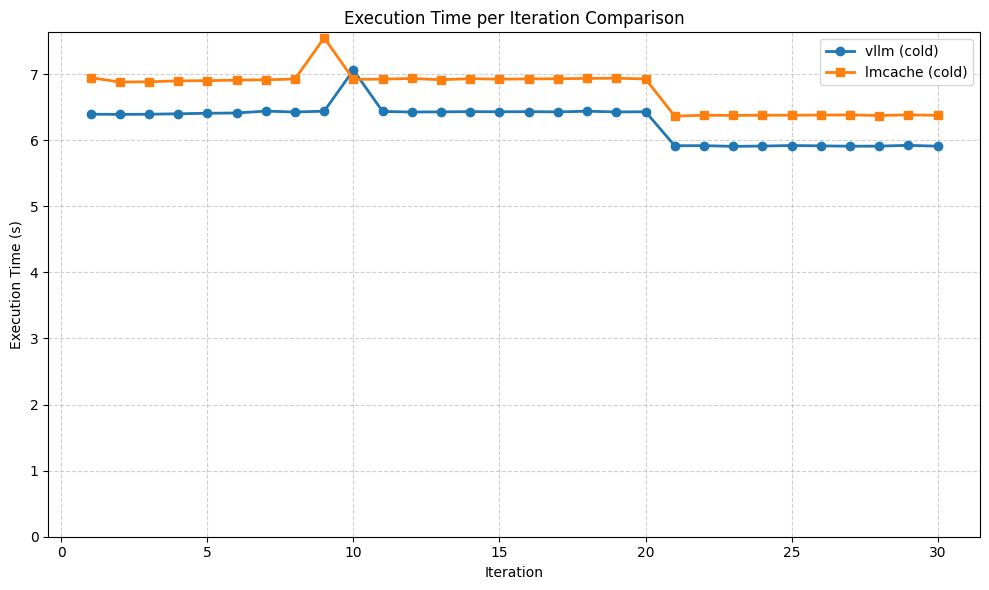

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

iterations = np.arange(1, len(time_cold_lmcache) + 1)

plt.figure(figsize=(10, 6))
plt.plot(iterations, time_cold_vllm, marker='o', label='vllm (cold)', linewidth=2)
plt.plot(iterations, time_cold_lmcache, marker='s', label='lmcache (cold)', linewidth=2)

# # Annotate each point with the value
# for i, (a, b) in enumerate(zip(times_a, times_b)):
#     plt.text(iterations[i], a + 0.02, f"{a:.2f}", ha='center', fontsize=8)
#     plt.text(iterations[i], b - 0.08, f"{b:.2f}", ha='center', fontsize=8, color='gray')
plt.ylim(bottom=0)
plt.xlabel("Iteration")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time per Iteration Comparison")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


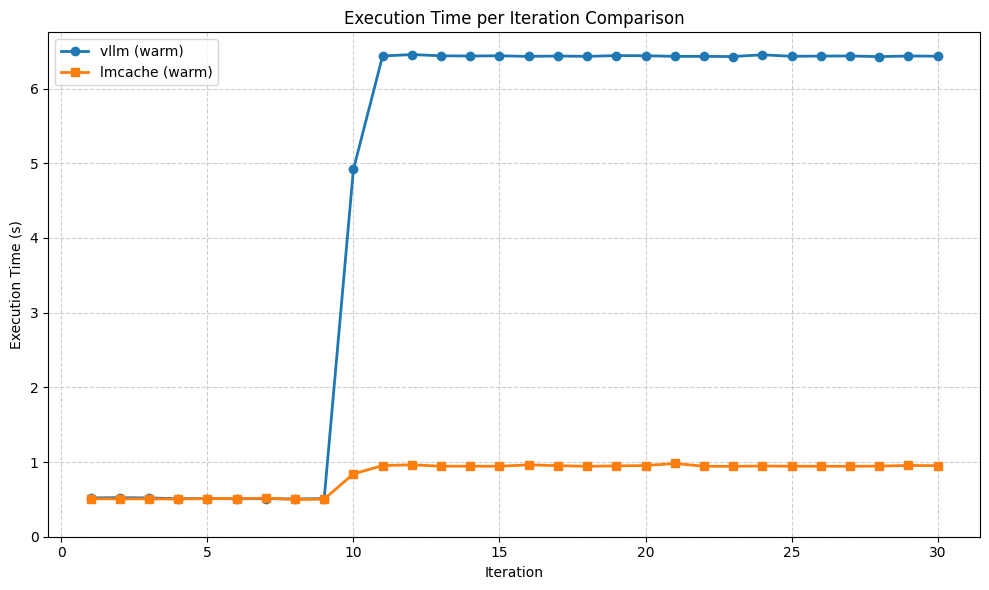

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

iterations = np.arange(1, len(time_cold_lmcache) + 1)

plt.figure(figsize=(10, 6))
plt.plot(iterations, time_warm_vllm, marker='o', label='vllm (warm)', linewidth=2)
plt.plot(iterations, time_warm_lmcache, marker='s', label='lmcache (warm)', linewidth=2)

# # Annotate each point with the value
# for i, (a, b) in enumerate(zip(times_a, times_b)):
#     plt.text(iterations[i], a + 0.02, f"{a:.2f}", ha='center', fontsize=8)
#     plt.text(iterations[i], b - 0.08, f"{b:.2f}", ha='center', fontsize=8, color='gray')
plt.ylim(bottom=0)
plt.xlabel("Iteration")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time per Iteration Comparison")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
run_vllm_bench(max_concurrency=1)
run_vllm_bench(max_concurrency=1)
run_vllm_bench(max_concurrency=5)

Running command:
 
    vllm bench serve       --backend vllm       --base-url http://localhost:8000       --endpoint /v1/completions       --dataset-name prefix_repetition       --prefix-repetition-num-prefixes 20       --prefix-repetition-prefix-len 40000       --prefix-repetition-suffix-len 10       --prefix-repetition-output-len 20       --num-prompts 20       --save-result       --append-result       --result-filename longctx_40k.json       --model Qwen/Qwen3-14B       --max-concurrency 1
    
2025-10-11 03:14:18.742650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760152458.764004   23006 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760152458.770643   23006 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to regist

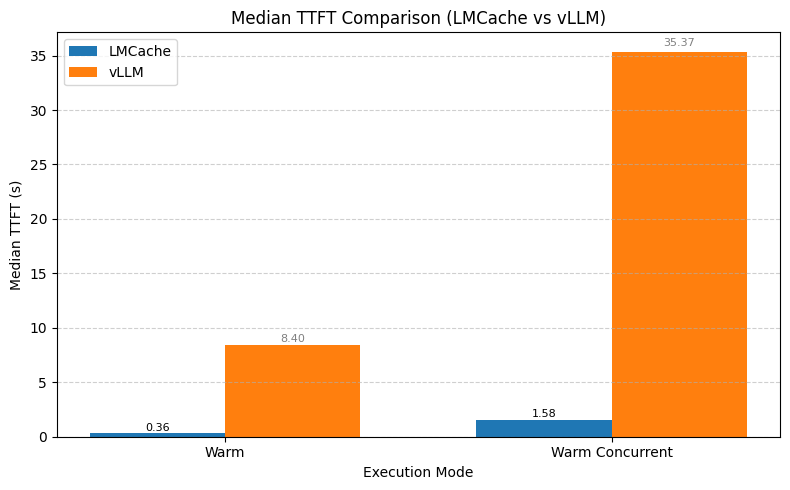

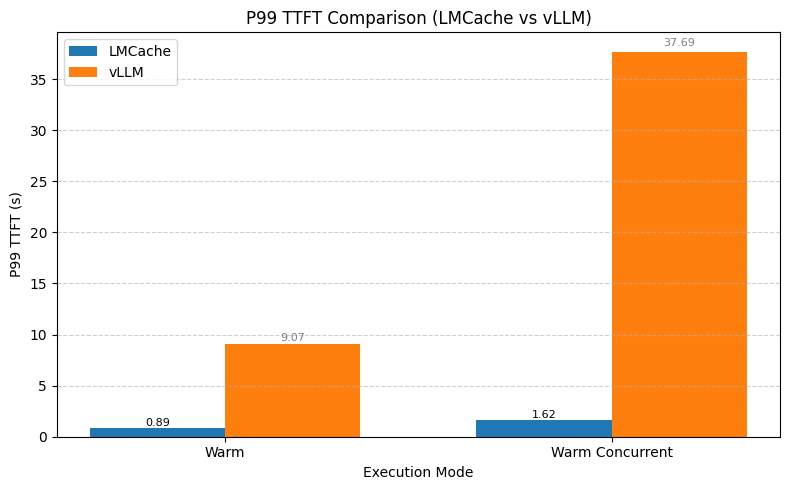

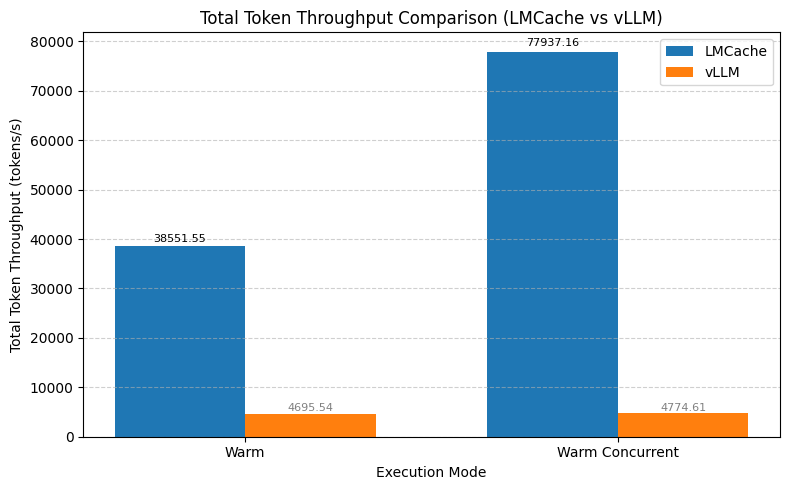

In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

with open("longctx_40k.json", "r") as f:
    data = [json.loads(line) for line in f if line.strip()]

# Order in file is assumed:
# 0: lmcache cold, 1: lmcache warm, 2: lmcache warm concurrent,
# 3: vllm cold,    4: vllm warm,    5: vllm warm concurrent

# Extract metrics (TTFT -> seconds)
median_ttft = [entry["median_ttft_ms"] / 1000 for entry in data]
p99_ttft = [entry["p99_ttft_ms"] / 1000 for entry in data]
total_token_throughput = [entry["total_token_throughput"] for entry in data]

# Keep only WARM / WARM CONCURRENT (drop cold)
group_labels = ["Warm", "Warm Concurrent"]
lmcache_median = [median_ttft[1], median_ttft[2]]
vllm_median    = [median_ttft[4], median_ttft[5]]

lmcache_p99 = [p99_ttft[1], p99_ttft[2]]
vllm_p99    = [p99_ttft[4], p99_ttft[5]]

lmcache_tput = [total_token_throughput[1], total_token_throughput[2]]
vllm_tput    = [total_token_throughput[4], total_token_throughput[5]]

def plot_comparison(lm_vals, vllm_vals, metric_name, ylabel):
    x = np.arange(len(group_labels))
    bar_width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - bar_width/2, lm_vals, bar_width, label='LMCache')
    plt.bar(x + bar_width/2, vllm_vals, bar_width, label='vLLM')

    # Labels
    for pos, val in zip(x - bar_width/2, lm_vals):
        plt.text(pos, val * 1.01 if val >= 0 else val - abs(val)*0.05,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=8)
    for pos, val in zip(x + bar_width/2, vllm_vals):
        plt.text(pos, val * 1.01 if val >= 0 else val - abs(val)*0.05,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=8, color='gray')

    plt.xlabel("Execution Mode")
    plt.ylabel(ylabel)
    plt.title(f"{metric_name} Comparison (LMCache vs vLLM)")
    plt.xticks(x, group_labels)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(bottom=0)  # start y-axis at 0
    plt.tight_layout()
    plt.show()

# Plots
plot_comparison(lmcache_median, vllm_median, "Median TTFT", "Median TTFT (s)")
plot_comparison(lmcache_p99,    vllm_p99,    "P99 TTFT",    "P99 TTFT (s)")
plot_comparison(lmcache_tput,   vllm_tput,   "Total Token Throughput", "Total Token Throughput (tokens/s)")